In [2]:
# create_classes.py
import os
imgs_dir = "/Users/user/Documents/GitHub/dataset/food-101/images"
classes = sorted([d for d in os.listdir(imgs_dir) if os.path.isdir(os.path.join(imgs_dir, d))])
with open("classes.txt", "w") as f:
    for c in classes:
        f.write(c + "\n")
print("Wrote classes.txt with", len(classes), "classes")


Wrote classes.txt with 101 classes


In [3]:
!pip3 install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 8.7 MB/s  0:00:23m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 9.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.4/667.4 kB 8.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 8.7 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 9.8 MB/s  0:00:02 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 9.8 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 9.8 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32/32 [tensorflow]2 [tensorflow]]


In [4]:

import tensorflow as tf
from tensorflow.keras import layers, models
import os

DATA_DIR = "/Users/user/Documents/GitHub/dataset/food-101/images"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS_HEAD = 6
EPOCHS_FINE = 6
NUM_CLASSES = 101  # Food-101

# 1) Prepare datasets (train/val split)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 2) Create the model
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # freeze

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="efficientnetb0_food101")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# 3) Train head
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_head.h5", monitor="val_accuracy", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)

# 4) Fine tune: unfreeze some of base model
base_model.trainable = True
# Freeze first N layers (optional) — helps stability
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_fine = [
    tf.keras.callbacks.ModelCheckpoint("best_finetuned.h5", monitor="val_accuracy", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_fine
)

# 5) Save final model (SavedModel format)
os.makedirs("saved_model", exist_ok=True)
model.save("saved_model/food_classifier")
print("Saved model to saved_model/food_classifier")


Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "efficientnetb0_food101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │        51,813 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,762,376 (18.17 MB)

 Trainable params: 710,245 (2.71 MB)

...

2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2984s 1s/step - accuracy: 0.6159 - loss: 1.4755 - val_accuracy: 0.6834 - val_loss: 1.2516
Epoch 4/6
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.6362 - loss: 1.3938

2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2663s 1s/step - accuracy: 0.6468 - loss: 1.3365 - val_accuracy: 0.6968 - val_loss: 1.1945
Epoch 5/6
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6529 - loss: 1.3115

2525/2525 ━━━━━━━━━━━━━━━━━━━━ 7926s 3s/step - accuracy: 0.6648 - loss: 1.2570 - val_accuracy: 0.7074 - val_loss: 1.1487
Epoch 6/6
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.6720 - loss: 1.2252

2525/2525 ━━━━━━━━━━━━━━━━━━━━ 2203s 872ms/step - accuracy: 0.6819 - loss: 1.1830 - val_accuracy: 0.7166 - val_loss: 1.1144


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=saved_model/food_classifier.

In [5]:
import os
import tensorflow as tf

# Make sure folder exists
os.makedirs("saved_model", exist_ok=True)

# Correct save format (choose one)
model.save("saved_model/food_classifier.keras")   # ✅ recommended

print("Model saved successfully!")


Model saved successfully!


In [6]:
model = tf.keras.models.load_model("saved_model/food_classifier.keras")


/opt/homebrew/Caskroom/miniconda/base/envs/foodmacros-n/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 131 variables whereas the saved optimizer has 260 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [7]:
import tensorflow as tf

# Load the saved model
model = tf.keras.models.load_model("saved_model/food_classifier.keras")

# Check model summary
model.summary()


Model: "efficientnetb0_food101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │        51,813 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,312,971 (35.53 MB)

 Trainable params: 4,550,593 (17.36 MB)

 Non-trainable params: 211,783 (827.28 KB)

 Optimizer params: 4,550,595 (17.36 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Actual Label: gyoza
Predicted Label: churros
❌ Incorrect!


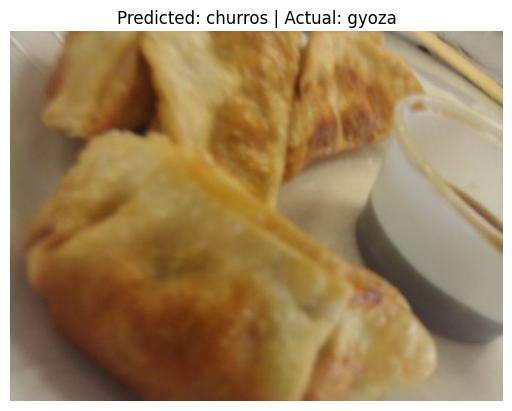

In [12]:
import sys
print(sys.executable)

/opt/homebrew/Caskroom/miniconda/base/envs/foodmacros-n/bin/python
